# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

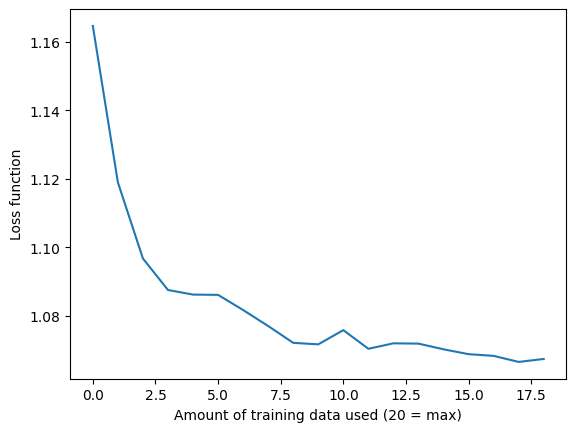

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

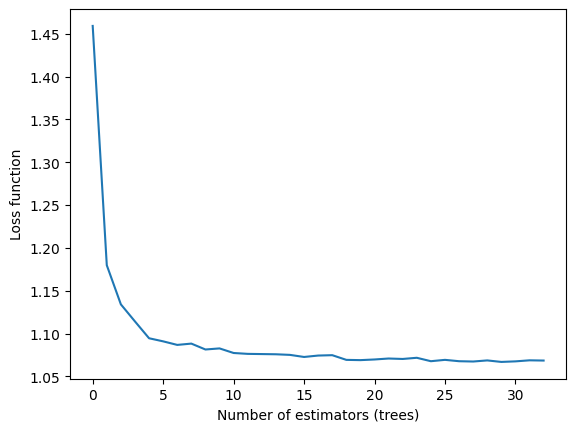

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Graph Reflection – Keep It Simple

I’d keep the cleaner graph—the one that shows performance with fewer distractions. Even if the other graph has more detail, it clutters the message. The simple version still tells the full story: how model performance changes over time or with more data.

As Vonnegut said, “have the guts to cut.” If a chart has extra lines, to much or unnecessarily long labels, or legends that don’t add clarity, they’re just noise.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

def model_and_plot_from_csv(csv_path, target_column, drop_columns=None, max_depth=None, plot_title=None):
    # Use fallback encoding for special characters
    df = pd.read_csv(csv_path, encoding="ISO-8859-1")

    # Drop user-specified non-feature columns
    if drop_columns:
        df = df.drop(columns=[col for col in drop_columns if col in df.columns])

    # Drop rows with missing data
    df = df.dropna()

    # Only keep numeric features for modeling
    X = df.drop(columns=[target_column])
    X = X.select_dtypes(include=[np.number])
    y = df[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Track performance vs. training size
    rmse_list = []
    corr_list = []
    train_sizes = np.linspace(0.1, 1.0, 10)

    for size in train_sizes:
        idx = int(size * len(X_train))
        model = RandomForestRegressor(n_estimators=100, max_depth=max_depth, random_state=42)
        model.fit(X_train[:idx], y_train[:idx])
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        corr, _ = pearsonr(y_test, preds)
        rmse_list.append(rmse)
        corr_list.append(corr)

    # Plot results
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(train_sizes, rmse_list, marker='o', color='tomato')
    ax[0].set_title("RMSE vs Training Size")
    ax[0].set_xlabel("Training Size (Fraction)")
    ax[0].set_ylabel("RMSE")
    ax[0].grid(True)

    ax[1].plot(train_sizes, corr_list, marker='o', color='steelblue')
    ax[1].set_title("Correlation vs Training Size")
    ax[1].set_xlabel("Training Size (Fraction)")
    ax[1].set_ylabel("Pearson Correlation")
    ax[1].grid(True)

    if plot_title:
        fig.suptitle(plot_title, fontsize=14)

    plt.tight_layout()
    plt.show()

    return rmse_list, corr_list

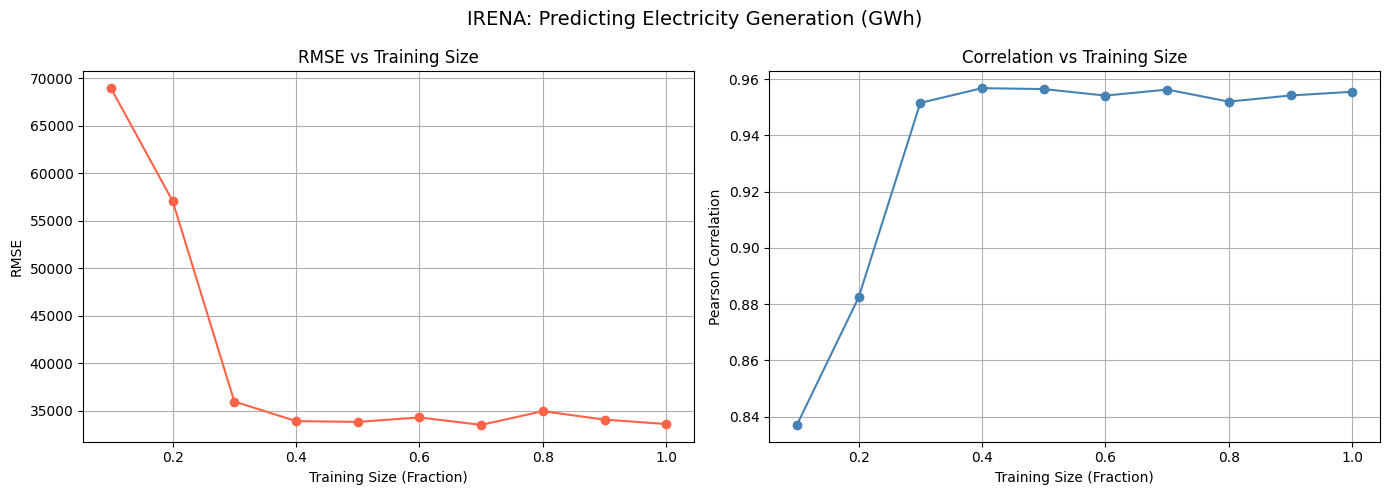

([np.float64(68939.80911901919),
  np.float64(57067.08828748848),
  np.float64(35964.012765793654),
  np.float64(33902.844874209084),
  np.float64(33817.42015305321),
  np.float64(34285.665161715835),
  np.float64(33502.952950268496),
  np.float64(34945.277362131455),
  np.float64(34057.22434841733),
  np.float64(33592.59445241989)],
 [np.float64(0.8370809613110131),
  np.float64(0.8823843147589818),
  np.float64(0.9515491026441543),
  np.float64(0.9567851574348019),
  np.float64(0.9564669555033862),
  np.float64(0.9541512250302349),
  np.float64(0.9562800906889988),
  np.float64(0.952007722427433),
  np.float64(0.9541821430592),
  np.float64(0.9555090376192326)])

In [30]:
model_and_plot_from_csv(
    csv_path="GlobalRenewEnergyProd_2000_2022/IRENA_RenewableEnergy_Statistics_2000-2022.csv",
    target_column="Electricity Generation (GWh)",
    drop_columns=[
        "Region", "Sub-region", "Country", "ISO3 code", "M49 code",
        "RE or Non-RE", "Technology", "Producer Type", "Year"
    ],
    plot_title="IRENA: Predicting Electricity Generation (GWh)"
)

### IRENA Dataset – Model Results

This model predicts electricity generation using numeric features from the IRENA dataset.

- The left chart shows RMSE dropping quickly as we increase training size—suggesting the model improves sharply with just a modest amount of data, then levels off.
- The right chart shows correlation with the target quickly rising and stabilizing near 0.95+, meaning the model aligns closely with actual values once it's trained on just 30–40% of the data.

Solid model performance. Time to move on to the next dataset!

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.